In [1]:
import jax
import equinox as eqx
import numpy as np
import jax.numpy as jnp
import immrax as irx
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import cvxpy as cp
import scipy
from immutabledict import immutabledict
from reach import *
from functools import partial
import control
from GPR import *
from TVGPR import *
from cyipopt import minimize_ipopt

# Some configurations
jax.config.update("jax_enable_x64", True)

# We wrap the jax.jit function t/o set the backend to cpu by default for convenience.
device = 'cpu'
def jit (*args, **kwargs):
    kwargs.setdefault('backend', device)
    return jax.jit(*args, **kwargs)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica",
    "font.size": 14
})

np.random.seed(0)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [2]:
# system dynamics and initial conditions

class PlanarMultirotor (irx.System) :
    def __init__ (self) :
        self.xlen = 5
        self.evolution = 'continuous'

    def f(self, t, x, u, w):
        px, py, vx, vy, theta = x.ravel()
        # u1, u2 = u.ravel()
        u1 = u[0]
        u2 = u[1]
        w1 = w[0]
        g = 9.81

        return jnp.array([
            vx,
            vy,
            -1*u1*jnp.sin(theta) + w1,
            u1*jnp.cos(theta) - g,
            u2
        ])
    
    def f_np(self, t, x, u, w):
        px, py, vx, vy, theta = x.ravel()
        u1 = u[0]
        u2 = u[1]
        w1 = w[0]
        g = 9.81

        return np.array([
            vx,
            vy,
            -1*u1*np.sin(theta) + w1,
            u1*np.cos(theta) - g,
            u2
        ])

sys = PlanarMultirotor()

# initial conditions
x0 = jnp.array([2.5, 6., 0., 0., 0.1])
u0 = jnp.array([9.81, 0.1])

w0 = jnp.array([0.0])

# x0_buf = 0.05 * jnp.array([1.0, 1.0, 1.0, 1.0, 1.0])
x0_buf = jnp.array([0.01, 0.01, 0.01, 0.01, 0.01])*0.05
ix0 = irx.icentpert(x0, x0_buf)
print(ix0)

ulim = irx.interval([-15, -3],[15, 3])

actual_disturbance_GP = GPR(jnp.array([[-2,-0.66005468347438],[0,1.71910828159421],[2,-2.73909534657961],[4,3.76474225408493],[6,3.65733558594356],[8,-0.116994810217270],[10,2.40224375111040],[12,-2.86490929098228]]), sigma_f = 5.0, l=2.0, sigma_n = 0.01)
def actual_disturbance_test (t, x) :
    return actual_disturbance_GP.mean(jnp.array([x[1]])).reshape(-1)

obs = jnp.array([[0.0, x0[1], actual_disturbance_test(0.0, x0)[0]], 
                    [0.0, x0[1], actual_disturbance_test(0.0, x0)[0]], 
                    [0.0, x0[1], actual_disturbance_test(0.0, x0)[0]],
                    [0.0, x0[1], actual_disturbance_test(0.0, x0)[0]],
                    [0.0, x0[1], actual_disturbance_test(0.0, x0)[0]],
                    [0.0, x0[1], actual_disturbance_test(0.0, x0)[0]],
                    [0.0, x0[1], actual_disturbance_test(0.0, x0)[0]]])

# GP = GPR(jnp.array([[1., 1.], [2., 1.0], [0., 1.]]), sigma_f = 1.0, l=2.0, sigma_n = 0.01)
# GP = GPR(jnp.array([[0.0, 1.], [1.0, 1.0], [-1.0, 0.5], [2.0, 1.0]]))
# GP = GPR(jnp.array([[0.0, 1.], [1.0, 1.0], [-1.0, 0.5], [0.5, 1.], [0.75, 0.5], [0.25, 1.]]), l=1.)


# print(sigma_if(0.0, ix0))


[[( 2.4995e+00, 2.5005e+00)]
 [( 5.9995e+00, 6.0005e+00)]
 [(-5.0000e-04, 5.0000e-04)]
 [(-5.0000e-04, 5.0000e-04)]
 [( 9.9500e-02, 1.0050e-01)]]


In [3]:
# determinant helper function, can't use np.linalg.det because it uses a primitive not in immrax
def getDet(mat, n=5):
  
    # Base case: if the matrix is 1x1
    if n == 1:
        return mat[0][0]
    
    # Base case for 2x2 matrix
    if n == 2:
        return mat[0][0] * mat[1][1] - \
               mat[0][1] * mat[1][0]
    
    # Recursive case for larger matrices
    res = 0
    for col in range(n):
      
        # Create a submatrix by removing the first 
        # row and the current column
        sub = [[0] * (n - 1) for _ in range(n - 1)]
        for i in range(1, n):
            subcol = 0
            for j in range(n):
              
                # Skip the current column
                if j == col:
                    continue
                
                # Fill the submatrix
                sub[i - 1][subcol] = mat[i][j]
                subcol += 1
        
        # Cofactor expansion
        sign = 1 if col % 2 == 0 else -1
        res += sign * mat[0][col] * getDet(sub, n - 1)
    
    return res

In [4]:
# Get initial P, K from LQR

# linearize system around x0, u0
A, B = jax.jacfwd(lambda x: sys.f(0, x, u0, [0]))(x0), jax.jacfwd(lambda u: sys.f(0, x0, u, [0]))(u0)
# print(A)
# print(B)

# weight matrices
Q = jnp.array([1, 1, 1, 1, 1]) * jnp.eye(sys.xlen)
R = jnp.array([1, 1]) * jnp.eye(2)

# LQR to get initial K, P
K, P, _ = control.lqr(A, B, Q, R)
feedback_K = -1 * K
print(feedback_K)

A, B = jax.jacfwd(lambda x: sys.f(0, x, u0, [0]))(x0*0.0), jax.jacfwd(lambda u: sys.f(0, x0, u, [0]))(u0)
Q = jnp.array([2000, 20, 500, 500, 1]) * jnp.eye(sys.xlen)
R = jnp.array([1, 20]) * jnp.eye(2)
K, P, _ = control.lqr(A, B, Q, R)
backup_K = -1 * K
print(backup_K)

[[ 9.98334166e-02 -9.95004165e-01  1.72916550e-01 -1.72339777e+00
  -9.25998451e-16]
 [ 9.95004165e-01  9.98334166e-02  1.44427207e+00  1.44910564e-01
  -5.42944692e+00]]
[[  5.41218599  -4.43926598   2.97952048 -22.39365974  -1.3617038 ]
 [  9.9265005    0.12102016   6.94647172   0.62854492 -11.67249174]]


In [5]:
# Simulation parameters
t0 = 0.     # Initial time
dt = 0.05  # Time step

T = 2.0   # Horizon for one step of the algorithm, T = 0.689 is the limit before ellipsoids explode with K_limiting
tt = np.arange(t0, T+dt, dt)
# print(tt)
# T = 0.1
# N = 5       # Number of iterations of the algorithm
# tf = T*N    # Final time

sys_mjacM = irx.mjacM(sys.f)
sys_jacM = irx.jacM(sys.f)

perm = irx.Permutation((0, 1, 2, 3, 4, 5, 6, 7, 8))

# sigma_mjacM = irx.mjacM(sigma)
# sigma_jacM = irx.jacM(sigma)
# sigma_perm = irx.Permutation((0, 1, 3, 4, 5, 2))

# print(sigma(0.0, x0)) 

# sigma_if = lambda t, x : irx.icentpert(0.0, irx.natif(sigma)(t, x).upper)

# print(sigma_if(0.0, ix0))

# def upper_bound(t, x):
#     return GP.mean(jnp.array([x[1]])).reshape(-1) + sigma(t, x)#jnp.sqrt(GP.variance(jnp.array([x[1]])).reshape(-1))

# def lower_bound(t, x):
#     return GP.mean(jnp.array([x[1]])).reshape(-1) - sigma(t, x)#jnp.sqrt(GP.variance(jnp.array([x[1]])).reshape(-1))

# dist_if = lambda t, x : irx.interval(irx.natif(lower_bound)(t, x).lower, irx.natif(upper_bound)(t, x).upper)  
# test_interval = irx.icentpert(x0, jnp.array([1, 1, 1, 1, 1]))
# print(dist_if(0.0, test_interval))
# print(mean_disturbance(0.0, x0))
# print(dist_if(0.0, test_interval) - mean_disturbance(0.0, x0))

In [6]:
from itertools import product
# CBF CODE
@jit
def LSE(s, P):
    return (-1/P) * jnp.log(jnp.sum(jnp.exp(-P*s)))

def LSE_h(a, p=5):
    def h_fun(x):
        return -1*(10*(x[0]**2 - 0.0625) -  x[1])
        # return -1*(5*(x[0]**2 - 0.0625) -  x[1])
        # return jnp.maximum(-1*(5*(x[0]**2 - 0.0625) -  x[1]), x[3])
    h_arr = jnp.array([h_fun(ac) for ac in a])
    return LSE(h_arr, p)

# print(M_all)
sh_x = ix0.shape
ic_x = jnp.isclose(ix0.lower.reshape(-1), ix0.upper.reshape(-1))
cs_x = [irx.Corner(p) for p in product(*[(0,) if ic_x[i] else (0,1) for i in range(len(ic_x))])]
@jit
def gsc_x (ix) :
    ix = ix.reshape(-1)
    return [jnp.array([ix.lower[i] if ci == 0 else ix.upper[i] for i, ci in enumerate(c)]).reshape(sh_x) for c in cs_x]

# assumed single embedding state is input
@jit
def gamma(x):
    print(x)
    corners = gsc_x(irx.interval(x[0:5], x[5:]))
    print(len(corners))
    return LSE_h(corners)

@jit
def PHI(tt, xx):
    gamma_arr = jnp.array([gamma(x) for x in xx])
    return tt[jnp.argmax(gamma_arr)], jnp.max(gamma_arr)

gamma(irx.i2ut(ix0))

d_LSEh_func = lambda x : jax.jacfwd(gamma, argnums=(0,))(irx.i2ut(ix0))[0]
print(d_LSEh_func(x0))

Traced<ShapedArray(float64[10])>with<DynamicJaxprTrace(level=1/0)>
32
[-21.88679672   0.50125     -0.          -0.          -0.
 -28.11444681   0.49875     -0.          -0.          -0.        ]


In [7]:

@partial(jit, static_argnames=('mjacM',))
def rollout (t_init, ix, xc, K_feed, K_backup, obs, mjacM=True) :
    # mjacM=True
    def mean_disturbance (t, x) :
            return GP.mean(jnp.hstack((t, x[1]))).reshape(-1)    

    def sigma(t, x):
        return jnp.sqrt(GP.variance(jnp.hstack((t, x[1]))).reshape(-1))

    def sigma_bruteforce_if(t, ix):
        div = 100
        x_list = [ix.lower + ((ix.upper - ix.lower)/div)*i for i in range(div)]
        sigma_list = 3.0*jnp.array([sigma(t, x) for x in x_list])
        return irx.interval(jnp.array([jnp.min(sigma_list)]), jnp.array([jnp.max(sigma_list)]))
    
    def step (carry, t) :
        xtut, xnomt, M, uM, wM, G, sig_range, MS, it, t_star, gamma_star, d_LSE, S_t, S_star = carry
        # uint = irx.icentpert(unomt, 1)
        # unomt = jnp.array([9.0 + 0.1*t, 0.1])
        xnom_backup = xnomt
        xnom_backup = xnom_backup.at[1].set(xnom_backup[1] - 4.0)
        # xnom_backup = xnom_backup.at[1].set(0.0)
        ubackup = (K_backup @ xnom_backup) + jnp.array([9.81, 0.0])

    
        unomt = jnp.array([jnp.minimum(jnp.maximum(ubackup[0], ulim.lower[0]), ulim.upper[0]),
            jnp.minimum(jnp.maximum(ubackup[1], ulim.lower[1]), ulim.upper[1])])
        # print(unomt)

        # test values
        # wnomt = jnp.array([0.0])
        # wint = irx.icentpert(wnomt, jnp.array([1.]))
        wnomt = GP.mean(jnp.array([t, xnomt[1]])).reshape(-1)
        # sigma_int = irx.icentpert(0.0, sigma(t, xnomt))
        # wint = irx.interval(wnomt) + sigma_if(t, irx.ut2i(xtut))
        # wint = dist_if(t, irx.ut2i(xtut))
        # w_diff = wint - wnomt

        # buffer sampled sigma bound with lipschitz constant to recover guarantee
        xint = irx.ut2i(xtut)
        x_div = (xint.upper - xint.lower)/(100*2)
        sigma_lip = MS @ x_div.T

        # w_diff = sigma_if(t, irx.ut2i(xtut)) 
        w_diff = sigma_bruteforce_if(t, irx.ut2i(xtut))
        w_diffint = irx.icentpert(0.0, w_diff.upper + sigma_lip.upper[1])
        wint = irx.interval(wnomt) + w_diffint

        


        if mjacM :
            Mt, Mx, Mu, Mw = sys_mjacM(irx.interval(t), irx.ut2i(xtut), ulim, wint,
                                centers=((jnp.array([t]), xnomt, unomt, wnomt),), 
                                permutations=(perm,))[0]
            _, MG = G_mjacM(irx.interval(jnp.array([t])), irx.ut2i(xtut), 
                         centers=((jnp.array([t]), xnomt,),), 
                         permutations=(G_perm,))[0]
            # _, MS = sigma_mjacM(irx.interval(0.), irx.ut2i(xtut), 
            #              centers=((jnp.array([0.]), xnomt),), 
            #              permutations=(sigma_perm,))[0]
            # print(MG)
        else :
            # Mt, Mx = sys_mjacM(irx.interval(0.), irx.ut2i(xtut), 
            #                     centers=((jnp.array([0.]), xnomt),), 
            #                     permutations=(perm,))[0]
            # _Mt, _Mx = sys_jacM(irx.interval(0.), irx.ut2i(xtut))
            Mt, Mx, Mu, Mw = sys_jacM(irx.interval(0.), irx.ut2i(xtut), ulim, wint)
            _, MG = G_jacM(irx.interval(0.), irx.ut2i(xtut))
            # _, MS = sigma_mjacM(irx.interval(0.), irx.ut2i(xtut))

        Mt = irx.interval(Mt)
        Mx = irx.interval(Mx)
        Mu = irx.interval(Mu)
        Mw = irx.interval(Mw)
        # MG = irx.interval(MG)

        # F = lambda t, x, u : (Mx + Mu@K)@(x - xnomt) + Mu@(unomt) + sys.f(0., xnomt, unomt) # not 100% sure about this
        
        # F = lambda t, x, u, w : (Mx + Mu@K)@(x - xnomt) + Mw@(w - wnomt) + sys.f(0., xnomt, unomt, wnomt) # without GP Jac
        F = lambda t, x, u, w: (Mx + Mu@K_feed + Mw@MG)@(x - xnomt) + Mw@w_diffint + sys.f(0., xnomt, unomt, wnomt) # with GP Jac
        
        # F = irx.natif(sys.f)
        embsys = irx.ifemb(sys, F)
        xnomtp1 = xnomt + dt*sys.f(t, xnomt, unomt, wnomt)
        # embsysdt = embsys.E(irx.interval(jnp.array([t])), xtut, unomt, wint)
        xtutp1 = xtut + dt*embsys.E(irx.interval(jnp.array([t])), xtut, unomt, wint)
        # print(xtutp1)
        # TODO: i don't think this is right, do the math to confirm but should be a good placeholder
        # embsysjac_1 = jnp.hstack(((Mx + Mu@K + Mw@MG).lower, jnp.zeros((5, 5))))
        # embsysjac_2 = jnp.hstack((jnp.zeros((5, 5)), (Mx + Mu@K + Mw@MG).upper))
        # embsysjac = jnp.vstack((embsysjac_1, embsysjac_2))
        embsysjac = jax.jacfwd(embsys.E, argnums=(1,))(irx.interval(jnp.array([t])), xtutp1, unomt, wint)[0]
        S_t = S_t + dt*(embsysjac@S_t)

        new_gamma = gamma(xtutp1)
        g_index = jnp.argmax(jnp.array([gamma_star, new_gamma]))
        gamma_star = jnp.array([gamma_star, new_gamma])[g_index]
        t_star = jnp.array([t_star, t])[g_index]
        d_LSE = jnp.array([d_LSE, jax.jacfwd(gamma, argnums=(0,))(xtutp1)[0]])[g_index]
        S_star = jnp.array([S_star, S_t])[g_index]
        
        # MG = jax.jacfwd(mean_disturbance, argnums=(1,))(0., xnomt)[0][0]
        return ((xtutp1, xnomtp1, M|Mx, uM|Mu, wM|Mw, G|MG, sig_range|w_diff, MS, it + 1, t_star, gamma_star, d_LSE, S_t, S_star), (xtutp1, xnomtp1, unomt))
    # unomt = jnp.array(u0)
    GP = TVGPR(obs, sigma_f = 5.0, l=2.0, sigma_n = 0.01, epsilon=0.25)
    tt = jnp.arange(0, T, dt) + t_init
    J0 = jax.jacfwd(sys.f, argnums=(1,))(t_init, xc, u0, w0)[0]
    Ju = jax.jacfwd(sys.f, argnums=(2,))(t_init, xc, u0, w0)[0]
    Jw = jax.jacfwd(sys.f, argnums=(3,))(t_init, xc, u0, w0)[0]
    G0 = jax.jacfwd(mean_disturbance, argnums=(1,))(t_init, xc)[0]
    sig0 = irx.icentpert(0.0, sigma(t_init, xc))

    G_mjacM = irx.mjacM(mean_disturbance)
    G_jacM = irx.jacM(mean_disturbance)
    G_perm = irx.Permutation((0, 1, 3, 4, 5, 2))

    MS0 = jax.jacfwd(sigma, argnums=(1,))(t_init, xc)[0]
    t_star = t_init
    gamma_star = gamma(irx.i2ut(ix))
    S_t = jnp.vstack((jnp.eye(5), jnp.eye(5)))
    S_star = S_t
    d_LSE = d_LSEh_func(irx.i2ut(ix))
    carry, xx = jax.lax.scan(step, (irx.i2ut(ix), xc, irx.interval(J0), irx.interval(Ju), irx.interval(Jw), irx.interval(G0), sig0, irx.interval(MS0), 0, t_star, gamma_star, d_LSE, S_t, S_star), tt)
    # return jnp.vstack((irx.i2ut(ix), xx[0])), jnp.vstack((xc, xx[1])), carry[2], carry[3], carry[4], jnp.vstack((u0, xx[2])), carry[5], carry[6]
    return jnp.vstack((irx.i2ut(ix), xx[0])), jnp.vstack((xc, xx[1])), jnp.vstack(xx[2]), carry[9], carry[10], carry[11], carry[13]

# xx, xxnom, M, Mu, Mw, unom_arr, G, sig_range = rollout(ix0, x0, K, u_ref)
xx, xxnom, unom_arr, t_star, PHI_x, d_LSE, S_star = rollout(0.0, ix0, x0, feedback_K, backup_K, obs)
print(xx.shape)
print(xxnom.shape)
print(unom_arr.shape)
print(t_star)
print(PHI_x)
print(d_LSE)
print(S_star)
print(d_LSE @ S_star)
print(d_LSE @ S_star @ sys.f_np(0., x0, u0, w0))
# print(M.shape)
# print(Mu.shape)
# print(Mw.shape)
# print(unom_arr.shape)
# print(G)
# if np.any(np.isnan(np.array(G.lower))) : raise ValueError("NaN in G")
# print(sig_range)
# print((Mw@G).shape)

(41, 10)
(41, 5)
(40, 2)
0.9
-23.22059649301555
[ 2.14828312e-56  9.70476465e-01 -0.00000000e+00 -0.00000000e+00
 -0.00000000e+00 -3.38116207e+01  2.95235350e-02 -0.00000000e+00
 -0.00000000e+00 -0.00000000e+00]
[[ 0.58753557  0.06694574  0.22795155  0.1703159  -0.65077012]
 [-0.27005656  0.71178227 -0.48330401  0.39357525  0.39814114]
 [-0.86937227  0.10712973 -0.72160991  0.11531392  0.81786314]
 [-0.39643379 -0.53082944 -0.76209861 -0.0813621   1.14809238]
 [-0.09311342  0.03051462 -0.10027428  0.08409546 -0.02821707]
 [ 0.60363637  0.05405534  0.25198032  0.14754476 -0.63256978]
 [-0.25279425  0.69620883 -0.4578749   0.36905799  0.40930704]
 [-0.80992794  0.03717713 -0.62673877  0.0085629   0.90601899]
 [-0.28514731 -0.61022183 -0.64711815 -0.24108016  1.30737996]
 [-0.07981586  0.01725887 -0.08050645  0.06338154 -0.01208496]]
[-20.6794708   -1.11637634  -9.00241624  -4.59587594  21.78668029]
11.220566685824062


In [8]:
xx, xxnom, unom_arr, t_star, PHI_x, d_LSE, S_star = rollout(0.0, ix0, x0, feedback_K, backup_K, obs)
print(t_star)
print(d_LSE @ S_star @ sys.f_np(0., x0, [0.0, 0.0], w0))
print(PHI_x)

0.9
45.085542984486956
-23.22059649301555


In [9]:
# cvxpy solve for filtered u
def u_ASIF(u_desired, x, PHI, d_LSE, S_star, sys):

    u = cp.Variable((2,))
    d_PHI = np.array(d_LSE @ S_star)
    # print(d_PHI)
    # sys.f_np(0, x, u, np.array([0]))
    # print(d_PHI@sys.f_np(0, x, u, np.array([0])))
    cons = []
    cons.extend([d_PHI@sys.f_np(0, x, u, np.array([0])) >= -(PHI**3)])
    cons.extend([u <= np.array(ulim.upper), u >= np.array(ulim.lower)])
    prob = cp.Problem(cp.Minimize(cp.norm(u - u_desired)), cons)
    prob.solve(solver=cp.MOSEK, mosek_params={'MSK_IPAR_NUM_THREADS': 10}, warm_start=True, verbose=False)
    return prob.status, u.value

u_ASIF(np.array([0., 0.]), x0, PHI_x, d_LSE, S_star, sys)

('infeasible', None)

In [12]:
#timing analysis
for i in range(100):
    xx, xxnom, unom_arr, t_star, PHI_x, d_LSE, S_star = rollout(0.0, ix0, x0, feedback_K, backup_K, obs)
    u_ASIF(np.array([0., 0.]), x0, PHI_x, d_LSE, S_star, sys)
    # gamma(xx[0])
    # PHI(tt, xx)

# forward rollout with resulting K
def fwd_rollout (sys, K_feed, xref, uref, T, dt) :
    def step (carry, ref) :
        xt = carry
        t, xr, unom = ref
        xt = xt + dt*sys.f(0., xt, unom + K_feed @ (xt - xr), actual_disturbance(t, xt))  
        return xt, xt
    tt = jnp.arange(0, T, dt)
    return jnp.vstack([x0, jax.lax.scan(step, (x0), (tt, xref, uref))[1]])

xa = fwd_rollout(sys, feedback_K, xxnom[:-1], unom_arr, T, dt)
print(xa)
uint = irx.interval([0, -1],[15, 1])
# for i in range(len(unom_arr)):
#     uapplied = unom_arr[i, :] + K@(xa[i, :] - xxnom[i, :])
#     print(uapplied)
#     if not np.all((uapplied > uint.lower) & (uapplied < uint.upper)):
#         raise ValueError("uapplied not in bounds")

In [12]:
def quadplot(xpos,ypos,rot,scale):
    ts=-.5*np.arange(np.pi,3/2*np.pi,.2)+.3
    xtemp=np.cos(ts)
    ytemp=np.sin(ts)*np.cos(ts)

    xs=np.hstack((.4*xtemp-1,-1,-1,1,1,.4*xtemp+1))
    ys=np.hstack((.3*ytemp+.4,.4,0,0,.4,.3*ytemp+.4))
    xs=scale*xs
    ys=scale*ys
    rotmat=np.array([[np.cos(rot),-np.sin(rot)],[np.sin(rot),np.cos(rot)]])
    # print(xs)
    newpos=rotmat@np.vstack((xs,ys))
    xs=newpos[0,:]+xpos
    ys=newpos[1,:]+ypos
    return xs,ys

quadplot(0, 0, 0, 1)

(array([-0.88179192, -0.92053227, -0.96006663, -1.        , -1.03993337,
        -1.07946773, -1.11820808, -1.15576734, -1.        , -1.        ,
         1.        ,  1.        ,  1.11820808,  1.07946773,  1.03993337,
         1.        ,  0.96006663,  0.92053227,  0.88179192,  0.84423266]),
 array([0.31530363, 0.34158725, 0.3701996 , 0.4       , 0.4298004 ,
        0.45841275, 0.48469637, 0.50760341, 0.4       , 0.        ,
        0.        , 0.4       , 0.31530363, 0.34158725, 0.3701996 ,
        0.4       , 0.4298004 , 0.45841275, 0.48469637, 0.50760341]))

In [13]:
test_int = irx.interval([1.00709393,  5.99041618,0.2016108, -0.16282727,0.3995 ],
 [1.00809393,  5.99141618,  0.2026108, -0.16182727, 0.4005])
test_obs = jnp.array([[0.,         6.,         3.65728629],
 [0.,         6.,         3.65728629],
 [0.,         6.,         3.65728629],
 [0.,         6.,         3.65728629],
 [0.,         6.,         3.65728629],
 [0.,         6.,         3.65728629],
 [0.05,       6.,         3.60836119]])
test_state = jnp.array([ 1.00759393,  5.99091618,  0.2021108,  -0.16232727,  0.4       ])
test_time = 0.1
xx, xxnom, unom_arr, t_star, PHI_x, d_LSE, S_star = rollout(test_time, test_int, test_state, feedback_K, backup_K, test_obs)
    
print(gamma(irx.i2ut(test_int)))

print(xx.shape)

print(xxnom.shape)
print(unom_arr.shape)
print(t_star)
print(PHI_x)
print(d_LSE)
print(S_star)


-4.22994310737527
(41, 10)
(41, 5)
(40, 2)
0.55
-2.8563691994330904
[-1.49831265e-11  5.38083938e-01 -0.00000000e+00 -0.00000000e+00
 -0.00000000e+00 -1.87142926e+01  4.61916062e-01 -0.00000000e+00
 -0.00000000e+00 -0.00000000e+00]
[[ 0.90792376  0.04183154  0.35555432  0.0763336  -0.48423218]
 [-0.05108738  0.91761273 -0.07658208  0.34828291 -0.23188484]
 [-0.52202233  0.11543195  0.14931248  0.2070636  -0.9833809 ]
 [-0.19327909 -0.32729843 -0.29725586  0.35770851 -0.36848547]
 [ 0.08347554  0.04371143  0.168891    0.07926423 -0.31963684]
 [ 0.90525285  0.03836753  0.35112263  0.07352233 -0.48144014]
 [-0.0546701   0.91505676 -0.08258417  0.34552069 -0.22750712]
 [-0.54329176  0.07124816  0.11361217  0.18104002 -0.95363038]
 [-0.22228319 -0.34786491 -0.34667835  0.33737104 -0.32501532]
 [ 0.08006703  0.03944624  0.16322534  0.0759627  -0.31598108]]


In [14]:
# RUN SIMULATION AND SAVE ANIMATION
import matplotlib.animation as animation

def u_desired(x):
    # sample desired input
    # return np.array([9.8, 0.0])
    return (backup_K @ x) + np.array([9.0, 0.0])

def u_backup(x): # make sure this matches what you used in rollout
    x = x.at[1].set(x[1] - 4.0)
    ubackup = (backup_K @ x) + np.array([9.81, 0.0])
    unomt = np.array([np.minimum(np.maximum(ubackup[0], ulim.lower[0]), ulim.upper[0]),
            np.minimum(np.maximum(ubackup[1], ulim.lower[1]), ulim.upper[1])])
    return unomt

current_state = x0
current_int = irx.icentpert(current_state, x0_buf)
current_time = 0.0
sim_dt = 0.05

# setup disturbance behavior
np.random.seed(0)
actual_disturbance_GP_f = GPR(jnp.array([[-2,-0.66005468347438],
                                       [0,1.71910828159421],
                                       [2,-2.73909534657961],
                                       [4,3.76474225408493],
                                       [6,3.65733558594356],
                                       [8,-0.116994810217270],
                                       [10,2.40224375111040],
                                       [12,-2.86490929098228],
                                       ]), 
                                       sigma_f = 5.0, 
                                       l=2.0, 
                                       sigma_n = 0.01
                                       )
actual_disturbance_GP_g = GPR(jnp.array([[-2,2.80494480741922],
                                       [0,-1.65967058757266],
                                       [2,-2.21529178685802],
                                       [4,-2.41828274757721],
                                       [6,-0.976879063072681],
                                       [8,-2.89172701466510],
                                       [10,-3.91337304908981],
                                       [12,-3.33944976072828],
                                       ]),
                                        sigma_f = 5.0,
                                        l=2.0,
                                        sigma_n = 0.01,
                                        )
dist_f_time = 0.0
dist_update_mag = 1.0

def actual_disturbance (t, x, epsilon=0.25) :
    t_leftover = t % 1.0
    cur_val = actual_disturbance_GP_f.mean(jnp.array([x[1]])).reshape(-1)
    next_val = jnp.sqrt(1-epsilon)*actual_disturbance_GP_f.mean(jnp.array([x[1]])).reshape(-1) + jnp.sqrt(epsilon)*actual_disturbance_GP_g.mean(jnp.array([x[1]])).reshape(-1)
    return (1.0 - t_leftover)*cur_val + t_leftover*next_val


obs = jnp.array([[0.0, x0[1], actual_disturbance(0.0, x0)[0]], 
                    [0.0, x0[1], actual_disturbance(0.0, x0)[0]], 
                    [0.0, x0[1], actual_disturbance(0.0, x0)[0]],
                    [0.0, x0[1], actual_disturbance(0.0, x0)[0]],
                    [0.0, x0[1], actual_disturbance(0.0, x0)[0]],
                    [0.0, x0[1], actual_disturbance(0.0, x0)[0]],
                    [0.0, x0[1], actual_disturbance(0.0, x0)[0]]])

xx, xxnom, unom_arr, t_star, PHI_x, d_LSE, S_star = rollout(current_time, current_int, current_state, feedback_K, backup_K, obs)
desired_input = u_desired(current_state)
ASIF_status, applied_input = u_ASIF(desired_input, current_state, PHI_x, d_LSE, S_star, sys)
if ASIF_status != 'optimal':
    applied_input = u_backup(current_state)
flight_path = np.array([x0])


# PLOTTING
PLOT_OBS = True
SAVE_PDF = True

# PLOTTING
if PLOT_OBS:
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12, 5))
else:
    fig, ax = plt.subplots()
cbf_x = np.linspace(-1.5, 1.5, 100)
cbf_y = 10*(cbf_x**2 - 0.0625)
ax.plot(cbf_x, cbf_y, label='Safety Region', color='green')


FONTSIZE = 18
LINEWIDTH = 1
QUADSIZE = 0.1
OBSSIZE = 100
SCATTERORDER = -1
if SAVE_PDF:
    FONTSIZE = 24
    LINEWIDTH = 3
    QUADSIZE = 0.25
    OBSSIZE = 200
    SCATTERORDER = 10
    

arrow_points = np.mgrid[-4:4, -1:10].reshape(2, -1).T
arrow_dirs = arrow_points*0.0
for a in range(arrow_points.shape[0]):
    arrow_dirs[a, :] = [actual_disturbance(0.0, np.array([arrow_points[a, 0], arrow_points[a, 1], 0.0, 0.0, 0.0]))[0], 0.0]
wind_arrows = ax.quiver(arrow_points[:, 0], arrow_points[:, 1], arrow_dirs[:, 0], arrow_dirs[:, 1], color='tab:gray', alpha=0.5)


# mixed monotonicity tube
# t_index = int(t_star/dt)
t_index = -1
nominal = ax.plot(xxnom[:t_index+1,0], xxnom[:t_index+1,1], label='Backup Trajectory', linestyle="dashed", color="black", linewidth=LINEWIDTH)[0]
lower = ax.plot(xx[:t_index+1,0], xx[:t_index+1,1], label='Lower', color="tab:red", linewidth=LINEWIDTH)[0]
upper = ax.plot(xx[:t_index+1,5], xx[:t_index+1,6], label='Upper', color="tab:blue", linewidth=LINEWIDTH)[0]
# actual = ax.plot(xa[:t_index,0], xa[:t_index,1], label='Actual', linestyle="dashed")[0]
# flight = ax.plot(x0[0], x0[1], label='Flight Trajectory', color='black')[0]
start_rect = Rectangle((xx[0,0], xx[0,1]), xx[0,5] - xx[0,0], xx[0,6] - xx[0,1], linewidth=1.0, edgecolor='black', facecolor='none', linestyle="solid")
start_patch = ax.add_patch(start_rect)
# end_rect = Rectangle((xx[-1,0], xx[-1,1]), xx[-1,5] - xx[-1,0], xx[-1,6] - xx[-1,1], linewidth=1, edgecolor='tab:gray', facecolor='none', linestyle="dashed")
end_rect = Rectangle((xx[t_index,0], xx[t_index,1]), xx[t_index,5] - xx[t_index,0], xx[t_index,6] - xx[t_index,1], linewidth=1.0, edgecolor='black', facecolor='none', linestyle="solid")
end_patch = ax.add_patch(end_rect)
landing_rect = Rectangle((-0.25, -0.5), 0.5, 0.5, linewidth=1, edgecolor='tab:purple', facecolor='tab:purple')
ax.add_patch(landing_rect)
quad_x, quad_y = quadplot(x0[0], x0[1], x0[4], QUADSIZE)
quad = ax.plot(quad_x, quad_y, color='black', linewidth=LINEWIDTH)[0]

plt.axes(ax)
plt.xlabel('y', fontsize=FONTSIZE)
plt.ylabel('z', fontsize=FONTSIZE)
titletime = plt.title('t = %1.2f' % current_time, fontsize=FONTSIZE)
if not SAVE_PDF: plt.legend() 
if not SAVE_PDF: plt.grid()
# plt.gca().set_aspect('equal')
plt.gca().set_xlim([-4, 4])
plt.gca().set_ylim([-1, 7])

if PLOT_OBS:
    gp_query_points = np.array([[0.0, p] for p in np.linspace(-2, 12, 100)])
    plotTVGP = TVGPR(obs, sigma_f = 5.0, l=2.0, sigma_n = 0.01, epsilon = 0.25)
    mean_pts = jnp.array([plotTVGP.mean(gpqp) for gpqp in gp_query_points]).reshape(-1)
    actual_pts = jnp.array([actual_disturbance(gpqp[0], jnp.array([0., gpqp[1], 0., 0., 0.]))[0] for gpqp in gp_query_points]).reshape(-1)
    sig_pts = 3*jnp.array([jnp.sqrt(plotTVGP.variance(gpqp)) for gpqp in gp_query_points]).reshape(-1)
    
    observations = ax2.scatter(obs[:, 1], obs[:, 2], label='Observations', c=obs[:, 0], cmap='viridis', s=100, edgecolors='black', zorder=SCATTERORDER)
    actual = ax2.plot(gp_query_points[:, 1], actual_pts, label='Actual', color='black', linewidth=LINEWIDTH)[0]
    mean = ax2.plot(gp_query_points[:, 1], mean_pts, label='Mean', color='tab:blue', linewidth=LINEWIDTH)[0]
    upper_conf = ax2.plot(gp_query_points[:, 1], mean_pts + sig_pts, label='Confidence Bound', color='lightblue', linewidth=LINEWIDTH)[0]
    lower_conf = ax2.plot(gp_query_points[:, 1], mean_pts - sig_pts, color='lightblue', linewidth=LINEWIDTH)[0]


    plt.axes(ax2)
    plt.xlabel('z', fontsize=FONTSIZE)
    plt.ylabel('magnitude', fontsize=FONTSIZE)
    plt.title('Disturbance Behavior')
    if not SAVE_PDF: plt.legend() 
    plt.grid()
    # plt.gca().set_aspect('equal')
    plt.gca().set_xlim([-2, 12])
    plt.gca().set_ylim([-8, 8])

if SAVE_PDF:
    # plt.show()
    print("Saving pdf figure")
    filename = "pdf/iasif_withobs_%1.2f.pdf" % current_time
    plt.savefig(filename, format="pdf", bbox_inches="tight")

def update(frame):
    # apply input, update state/time
    global current_state, applied_input, current_time, flight_path, obs, arrow_points, wind_arrows, actual_disturbance_GP_f, actual_disturbance_GP_g, dist_f_time, plotTVGP, mean, actual, PLOT_OBS, observations, upper, lower, dist_update_mag, OBSSIZE
    print(current_time)
    print(current_state)
    print(applied_input)
    # while current_time < current_time + sim_dt:
    current_state = current_state + sim_dt * sys.f_np(current_time, current_state, applied_input, actual_disturbance(current_time, current_state))
    flight_path = np.vstack((flight_path, current_state))
    current_int = irx.icentpert(current_state, x0_buf)
    current_time = current_time + sim_dt
    
    # calculate new input
    # print(current_int)
    # print(current_state)
    # print(current_time)
    # print(obs)
    xx, xxnom, unom_arr, t_star, PHI_x, d_LSE, S_star = rollout(current_time, current_int, current_state, feedback_K, backup_K, obs)
    # print(xx.shape)
    # print(xxnom.shape)
    # print(unom_arr.shape)
    # print(t_star)
    # print(PHI_x)
    # print(d_LSE)
    # print(S_star)


    # xa = fwd_rollout(sys, feedback_K, xxnom[:-1], unom_arr, T, dt)
    desired_input = u_desired(current_state)
    print(desired_input)
    ASIF_status, applied_input = u_ASIF(desired_input, current_state, PHI_x, d_LSE, S_star, sys)
    if ASIF_status != 'optimal':
        print("NOT OPTIMAL")
        applied_input = u_backup(current_state)

    # if it's been 1 second, crete next portion of disturbance behavior
    if current_time >= dist_f_time + 1.0:
        dist_f_time = jnp.floor(current_time)
        actual_disturbance_GP_f = GPR(jnp.array([[-2, actual_disturbance(0.99, [0, -2])[0]],
                                    [0,actual_disturbance(0.99, [0, 0])[0]],
                                    [2,actual_disturbance(0.99, [0, 2])[0]],
                                    [4,actual_disturbance(0.99, [0, 4])[0]],
                                    [6,actual_disturbance(0.99, [0, 6])[0]],
                                    [8,actual_disturbance(0.99, [0, 8])[0]],
                                    [10,actual_disturbance(0.99, [0, 10])[0]],
                                    [12,actual_disturbance(0.99, [0, 12])[0]],
                                    ]), 
                                    sigma_f = 5.0, 
                                    l=2.0, 
                                    sigma_n = 0.01
                                    )
        actual_disturbance_GP_g = GPR(jnp.array([[-2, np.random.normal(scale=dist_update_mag)],
                                    [0,np.random.normal(scale=dist_update_mag)],
                                    [2,np.random.normal(scale=dist_update_mag)],
                                    [4,np.random.normal(scale=dist_update_mag)],
                                    [6,np.random.normal(scale=dist_update_mag)],
                                    [8,np.random.normal(scale=dist_update_mag)],
                                    [10,np.random.normal(scale=dist_update_mag)],
                                    [12,np.random.normal(scale=dist_update_mag)],
                                    ]),
                                    sigma_f = 5.0,
                                    l=2.0,
                                    sigma_n = 0.01,
                                    )
    

    # update plots
    t_index = int((t_star - current_time)/dt)
    # t_index = -1
    if PHI_x < 0 or ASIF_status != 'optimal': #if hyperrectangle is too large or convex problem failed, collect observations
        obs = jnp.vstack((obs[1:, :], jnp.array([[current_time, current_state[1], actual_disturbance(current_time, current_state)[0]]])))
        if PLOT_OBS: plotTVGP = TVGPR(obs, sigma_f = 5.0, l=2.0, sigma_n = 0.01, epsilon = 0.25)

    arrow_dirs = arrow_points*0.0
    for a in range(arrow_points.shape[0]):
        arrow_dirs[a, :] = [actual_disturbance(current_time, np.array([arrow_points[a, 0], arrow_points[a, 1], 0.0, 0.0, 0.0]))[0], 0.0]
    wind_arrows.set_UVC(arrow_dirs[:, 0], arrow_dirs[:, 1])

    lower.set_data(xx[:t_index+1,0], xx[:t_index+1,1])
    upper.set_data(xx[:t_index+1,5], xx[:t_index+1,6])
    nominal.set_data(xxnom[:t_index+1,0], xxnom[:t_index+1,1])

    quad_x, quad_y = quadplot(current_state[0], current_state[1], current_state[4], QUADSIZE)
    quad.set_data(quad_x, quad_y)

    # actual.set_data(xa[:t_index,0], xa[:t_index,1])
    # flight.set_data(flight_path[:,0], flight_path[:,1])
    start_patch.set_xy((xx[0,0], xx[0,1]))
    start_patch.set_width(xx[0,5] - xx[0,0])
    start_patch.set_height(xx[0,6] - xx[0,1])
    end_patch.set_xy((xx[t_index,0], xx[t_index,1]))
    end_patch.set_width(xx[t_index,5] - xx[t_index,0])
    end_patch.set_height(xx[t_index,6] - xx[t_index,1])
    titletime.set_text('t = %1.2f' % current_time)

    if PLOT_OBS:
        gp_query_points[:, 0] = current_time
        mean_pts = jnp.array([plotTVGP.mean(gpqp) for gpqp in gp_query_points]).reshape(-1)
        actual_pts = jnp.array([actual_disturbance(gpqp[0], jnp.array([0., gpqp[1], 0., 0., 0.]))[0] for gpqp in gp_query_points]).reshape(-1)
        sig_pts = 3*jnp.array([jnp.sqrt(plotTVGP.variance(gpqp)) for gpqp in gp_query_points]).reshape(-1)
        
        
        actual.set_data(gp_query_points[:, 1], actual_pts)
        mean.set_data(gp_query_points[:, 1], mean_pts)
        upper_conf.set_data(gp_query_points[:, 1], mean_pts + sig_pts)
        lower_conf.set_data(gp_query_points[:, 1], mean_pts - sig_pts)
        observations.set_offsets(obs[:, 1:])
        observations.set_sizes(OBSSIZE*jnp.exp(2*(obs[:, 0] - current_time)))
        if not SAVE_PDF: observations.set_alpha(jnp.exp(1.0*(obs[:, 0] - current_time)))

    if SAVE_PDF:
        if (frame) % 20 == 0:
            # plt.show()
            print("Saving pdf figure")
            filename = "pdf/iasif_withobs_%1.2f.pdf" % current_time
            plt.savefig(filename, format="pdf", bbox_inches="tight")

    return (lower, upper, nominal, start_patch, end_patch, titletime)

ani = animation.FuncAnimation(fig=fig, func=update, frames=400, interval=int(sim_dt*1000))
ani.save(filename="iasif_sim_tvgp_withobs_test.gif", writer="pillow")

Saving pdf figure
0.0
[2.5 6.  0.  0.  0.1]
[14.32576264  3.        ]
[-9.08986072 23.53744115]
NOT OPTIMAL
Saving pdf figure
0.05
[2.5        6.         0.11135482 0.22220967 0.25      ]
[9.47720319 3.        ]
[-8.42253784 22.26236225]
NOT OPTIMAL
Saving pdf figure
0.1
[2.50556774 6.01111048 0.174538   0.19083867 0.4       ]
[10.14452608  3.        ]
[-8.16328143 20.43671722]
NOT OPTIMAL
0.15000000000000002
[2.51429464 6.02065242 0.15324663 0.16752503 0.55      ]
[10.40378248  3.        ]
[-7.60688446 18.04159015]
NOT OPTIMAL
0.2
[2.52195697 6.02902867 0.05366094 0.12049902 0.7       ]
[10.96017945  3.        ]
[-6.77493166 14.99195663]
0.25
[ 2.52464002  6.03505362 -0.13078802  0.0491394   0.85      ]
[-6.77504042  3.        ]
[10.2158012  15.64337557]
0.3
[ 2.51810062  6.03751059  0.28895517 -0.66493123  1.        ]
[10.21578039  3.        ]
[14.24463013 12.03991493]
0.35
[ 2.53254838  6.00426403  0.0216045  -0.87945074  1.15      ]
[14.24467131  3.        ]
[17.26526732  6.7999585

SyntaxError: not a PNG file (<string>)

SyntaxError: not a PNG file (<string>)

<Figure size 1200x500 with 2 Axes>

NameError: name 'xa' is not defined

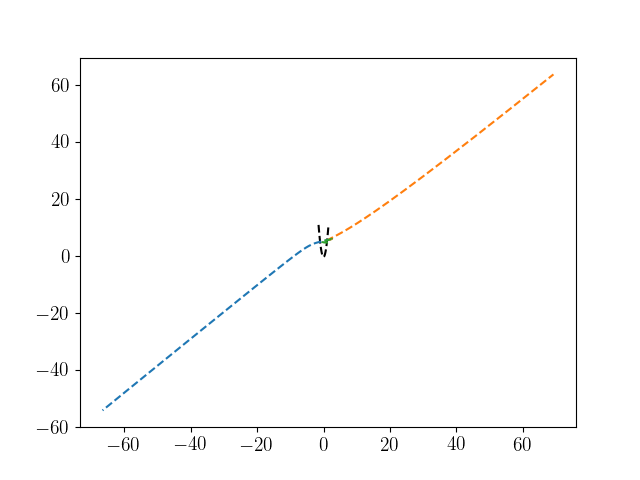

In [ ]:
%matplotlib ipympl

import shapely.ops as so

# plot trajectories
fig, ax = plt.subplots()

cbf_x = np.linspace(-1.5, 1.5, 100)
cbf_y = 5*(cbf_x**2 - 0.0625)
ax.plot(cbf_x, cbf_y, label='Safety Region', linestyle="dashed", color='black')

# mixed monotonicity tube
ax.plot(xx[:,0], xx[:,1], label='Lower', linestyle="dashed")
ax.plot(xx[:,5], xx[:,6], label='Upper', linestyle="dashed")
ax.plot(xxnom[:,0], xxnom[:,1], label='Nominal', linestyle="dashed")
ax.plot(xa[:,0], xa[:,1], label='Actual')
start_rect = Rectangle((xx[0,0], xx[0,1]), xx[0,5] - xx[0,0], xx[0,6] - xx[0,1], linewidth=1, edgecolor='tab:gray', facecolor='none')
ax.add_patch(start_rect)
end_rect = Rectangle((xx[-1,0], xx[-1,1]), xx[-1,5] - xx[-1,0], xx[-1,6] - xx[-1,1], linewidth=1, edgecolor='tab:red', facecolor='none')
ax.add_patch(end_rect)
landing_rect = Rectangle((-0.25, -0.5), 0.5, 0.5, linewidth=1, edgecolor='tab:green', facecolor='tab:green')
ax.add_patch(landing_rect)

# irx.utils.draw_iarrays(ax, [irx.ut2i(xxi) for xxi in xx], ec='tab:red')

plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid()
plt.gca().set_aspect('equal')
plt.gca().set_xlim([-5, 5])
plt.gca().set_ylim([-1, 7])
plt.show()




In [ ]:
# plot trajectories
fig, ax = plt.subplots()

# mixed monotonicity tube
plt.plot(xx[:,2], xx[:,3], label='Lower', linestyle="dashed")
plt.plot(xx[:,7], xx[:,8], label='Upper', linestyle="dashed")
plt.plot(xxnom[:,2], xxnom[:,3], label='Nominal', linestyle="dashed")
plt.plot(xa[:,2], xa[:,3], label='Actual')
start_rect = Rectangle((xx[0,2], xx[0,3]), xx[0,7] - xx[0,2], xx[0,8] - xx[0,3], linewidth=1, edgecolor='tab:gray', facecolor='none')
ax.add_patch(start_rect)
end_rect = Rectangle((xx[-1,2], xx[-1,3]), xx[-1,7] - xx[-1,2], xx[-1,8] - xx[-1,3], linewidth=1, edgecolor='tab:red', facecolor='none')
ax.add_patch(end_rect)

# irx.utils.draw_iarrays(ax, [irx.ut2i(xxi) for xxi in xx], 2, 3, ec='tab:red')

plt.xlabel('vx')
plt.ylabel('vy')
plt.legend()
plt.show()




In [ ]:
# plot trajectories
fig, ax = plt.subplots()

# mixed monotonicity tube
plt.plot(xx[:,2], xx[:,4], label='Lower', linestyle="dashed")
plt.plot(xx[:,7], xx[:,9], label='Upper', linestyle="dashed")
plt.plot(xxnom[:,2], xxnom[:,4], label='Nominal', linestyle="dashed")
plt.plot(xa[:,2], xa[:,4], label='Actual')
start_rect = Rectangle((xx[0,2], xx[0,4]), xx[0,7] - xx[0,2], xx[0,9] - xx[0,4], linewidth=1, edgecolor='tab:gray', facecolor='none')
ax.add_patch(start_rect)
end_rect = Rectangle((xx[-1,2], xx[-1,4]), xx[-1,7] - xx[-1,2], xx[-1,9] - xx[-1,4], linewidth=1, edgecolor='tab:red', facecolor='none')
ax.add_patch(end_rect)

# irx.utils.draw_iarrays(ax, [irx.ut2i(xxi) for xxi in xx], 2, 4, ec='tab:red')

plt.xlabel('vx')
plt.ylabel('theta')
plt.legend()
plt.show()


